In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Kết nối DuckDB → PostgreSQL ───────────────────────────────────────────────
PG = "dbname=risk_banking user=namphuong password=2104 host=localhost port=5432"
conn = duckdb.connect()
conn.execute("INSTALL postgres_scanner; LOAD postgres_scanner;")
conn.execute(f"ATTACH '{PG}' AS pg (TYPE postgres);")

# ── Style cho chart ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})
COLORS = {
    "navy":   "#1D4E89", "blue":  "#2E86AB",
    "teal":   "#1D9E75", "green": "#27AE60",
    "amber":  "#E67E22", "red":   "#C0392B",
    "purple": "#8E44AD", "gray":  "#5D6D7E",
}
print("✓ Kết nối thành công — sẵn sàng phân tích")

✓ Kết nối thành công — sẵn sàng phân tích


## 4.1 — Concentration Risk theo Grade

In [7]:
df_conc_g = conn.execute("""
    SELECT grade,
        COUNT(*) AS loan_count,
        ROUND(SUM(loan_amnt)/1e6, 2) AS total_amnt_m,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct_portfolio,
        ROUND(100.0 * SUM(loan_amnt)/SUM(SUM(loan_amnt)) OVER(), 2) AS amnt_pct,
        ROUND(100.0 * SUM(CASE WHEN debt_group>=3 THEN 1 ELSE 0 END)/COUNT(*),2) AS npl_pct,
        POWER(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS hhi_contrib
    FROM pg.accepted_loans
    WHERE grade IS NOT NULL
    GROUP BY grade ORDER BY grade
""").df()

hhi = df_conc_g["hhi_contrib"].sum()
print(df_conc_g.to_string(index=False))


grade  loan_count  total_amnt_m  pct_portfolio  amnt_pct  npl_pct  hhi_contrib
    A      433027       6323.64          19.15     18.59     3.59   366.907322
    B      663557       9404.82          29.35     27.65     8.64   861.554780
    C      650053       9775.55          28.75     28.74    14.34   826.844725
    D      324424       5097.34          14.35     14.99    20.29   205.945533
    E      135639       2367.32           6.00      6.96    28.17    35.999427
    F       41800        799.41           1.85      2.35    36.20     3.418842
    G       12168        248.03           0.54      0.73    39.41     0.289711


## 4.2 — Concentration Risk theo State

DTI Bucket vs NPL Rate (loan-level)
 dti_bucket  loan_count  npl_pct  avg_dti
        0.0       37881    10.20     1.42
        5.0      200369     9.63     5.38
       10.0      380116    10.39    10.17
       15.0      478297    11.69    15.02
       20.0      446225    13.24    19.92
       25.0      342006    14.93    24.84
       30.0      219242    16.59    29.74
       35.0      103896    17.59    34.47
       40.0       27989    16.10    39.04
       45.0        6654    11.42    44.87
       50.0        4256     9.47    49.72
       55.0        2704     7.03    54.83
       60.0        1013     8.98    58.68


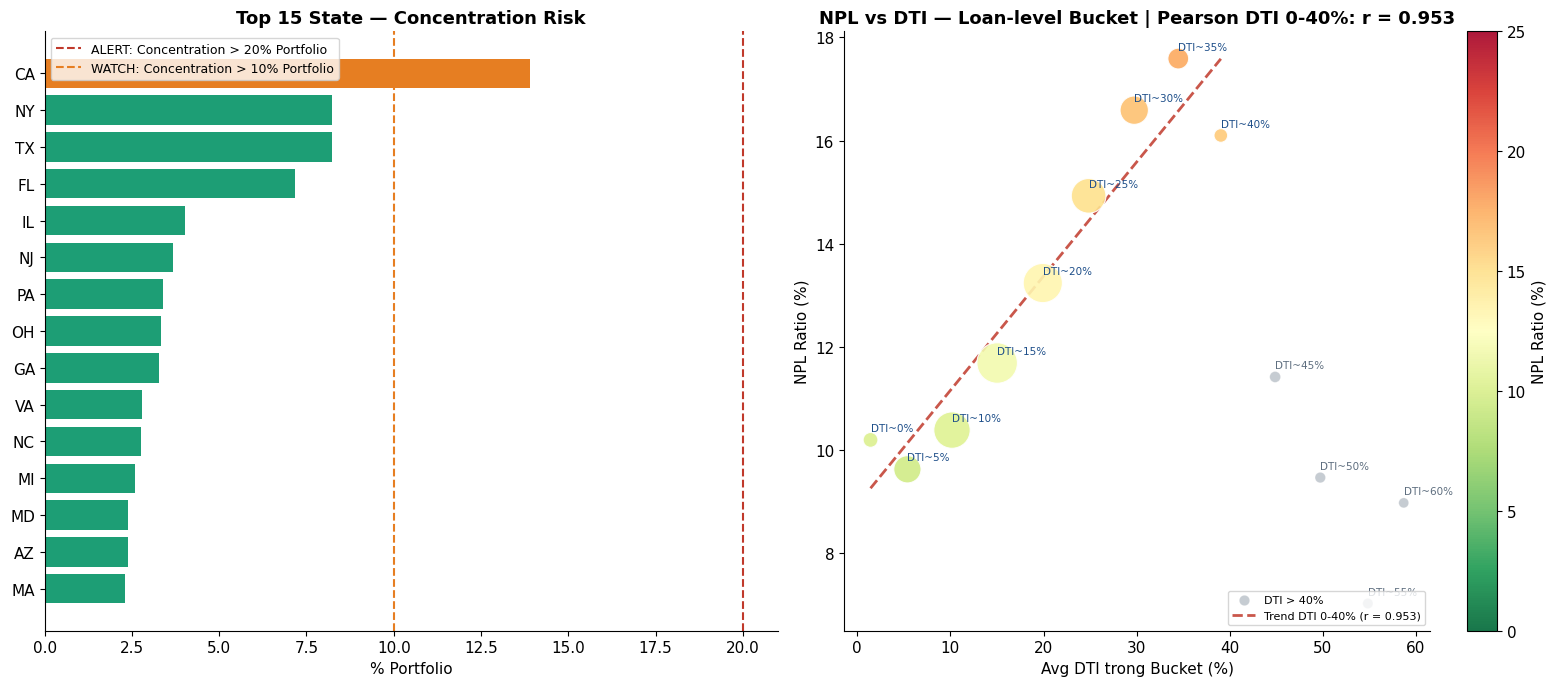

In [11]:
import numpy as np


df_conc_s = conn.execute("""
    SELECT
        addr_state,
        COUNT(*)                                                AS loan_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2)      AS pct_portfolio,
        ROUND(100.0 * SUM(CASE WHEN debt_group>=3
            THEN 1 ELSE 0 END) / COUNT(*), 2)                  AS npl_pct,
        ROUND(AVG(dti), 2)                                      AS avg_dti,
        CASE WHEN 100.0*COUNT(*)/SUM(COUNT(*)) OVER() > 20 THEN 'ALERT'
             WHEN 100.0*COUNT(*)/SUM(COUNT(*)) OVER() > 10 THEN 'WATCH'
             ELSE 'OK' END                                      AS flag
    FROM pg.accepted_loans
    WHERE addr_state IS NOT NULL
    GROUP BY addr_state
    ORDER BY loan_count DESC
    LIMIT 20
""").df()

# ── Query 2: DTI bucket → NPL loan-level 
# chia DTI thanh 10 bucket → tinh NPL trung binh moi bucket

df_dti = conn.execute("""
    SELECT
        ROUND(dti / 5.0) * 5                                   AS dti_bucket,
        COUNT(*)                                                AS loan_count,
        ROUND(100.0 * SUM(CASE WHEN debt_group >= 3
            THEN 1 ELSE 0 END) / COUNT(*), 2)                  AS npl_pct,
        ROUND(AVG(dti), 2)                                      AS avg_dti
    FROM pg.accepted_loans
    WHERE dti IS NOT NULL AND dti BETWEEN 0 AND 60
    GROUP BY ROUND(dti / 5.0) * 5
    ORDER BY dti_bucket
""").df()

print("DTI Bucket vs NPL Rate (loan-level)")
print(df_dti.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart trai: Top 15 State Concentration Risk 
top15 = df_conc_s.head(15)
bar_colors = [COLORS["red"]   if f == "ALERT"
              else COLORS["amber"] if f == "WATCH"
              else COLORS["teal"]
              for f in top15["flag"]]
axes[0].barh(top15["addr_state"][::-1], top15["pct_portfolio"][::-1],
             color=bar_colors[::-1])
axes[0].axvline(20, color=COLORS["red"],   linestyle="--", linewidth=1.5,
                label="ALERT: Concentration > 20% Portfolio")
axes[0].axvline(10, color=COLORS["amber"], linestyle="--", linewidth=1.5,
                label="WATCH: Concentration > 10% Portfolio")
axes[0].set_title("Top 15 State — Concentration Risk")
axes[0].set_xlabel("% Portfolio")
axes[0].legend(fontsize=9)

# ── Chart phai: NPL vs DTI Bucket

DTI_MAX_LINEAR = 40  # gioi han vung tuyen tinh
df_dti_core = df_dti[df_dti["dti_bucket"] <= DTI_MAX_LINEAR].copy()
df_dti_tail = df_dti[df_dti["dti_bucket"] >  DTI_MAX_LINEAR].copy()

xb_core = df_dti_core["avg_dti"]
yb_core = df_dti_core["npl_pct"]
sz_core = df_dti_core["loan_count"] / df_dti["loan_count"].max() * 800 + 50

# Ve tat ca bucket nhung phan biet mau
axes[1].scatter(df_dti_tail["avg_dti"], df_dti_tail["npl_pct"],
                s=df_dti_tail["loan_count"]/df_dti["loan_count"].max()*800+50,
                c=COLORS["gray"], alpha=0.35, edgecolors="white",
                linewidth=0.5, zorder=2, label="DTI > 40%")
sc = axes[1].scatter(xb_core, yb_core,
                     s=sz_core,
                     c=yb_core, cmap="RdYlGn_r", vmin=0, vmax=25,
                     alpha=0.9, edgecolors="white", linewidth=0.8, zorder=3)
for _, row in df_dti.iterrows():
    axes[1].annotate(f"DTI~{int(row['dti_bucket'])}%",
                     (row["avg_dti"], row["npl_pct"]),
                     fontsize=7.5, ha="left", va="bottom",
                     xytext=(0, 5), textcoords="offset points",
                     color=COLORS["gray"] if row["dti_bucket"] > DTI_MAX_LINEAR else COLORS["navy"])


from scipy import stats as sp_stats
slope, intercept, r_core, p_val, _ = sp_stats.linregress(xb_core, yb_core)
x_line = np.linspace(xb_core.min(), xb_core.max(), 100)
axes[1].plot(x_line, slope * x_line + intercept,
             color=COLORS["red"], linestyle="--", linewidth=2.0,
             alpha=0.85, label=f"Trend DTI 0-40% (r = {r_core:.3f})")

# Spearman cho toan bo range
from scipy.stats import spearmanr
rho, pval = spearmanr(df_dti["avg_dti"], df_dti["npl_pct"])

axes[1].set_title(
    f"NPL vs DTI — Loan-level Bucket | Pearson DTI 0-40%: r = {r_core:.3f}"
)
axes[1].legend(fontsize=8, loc="lower right")
plt.colorbar(sc, ax=axes[1], label="NPL Ratio (%)")
axes[1].set_xlabel("Avg DTI trong Bucket (%)")
axes[1].set_ylabel("NPL Ratio (%)")
corr_dti_bucket = r_core

plt.tight_layout()
plt.savefig("results/m4_concentration_state.png", dpi=150, bbox_inches="tight")
plt.show()


## 4.3 — Macro Overlay

Correlation NPL vs Unemployment Rate : 0.2710
Correlation NPL vs Fed Funds Rate    : -0.6866


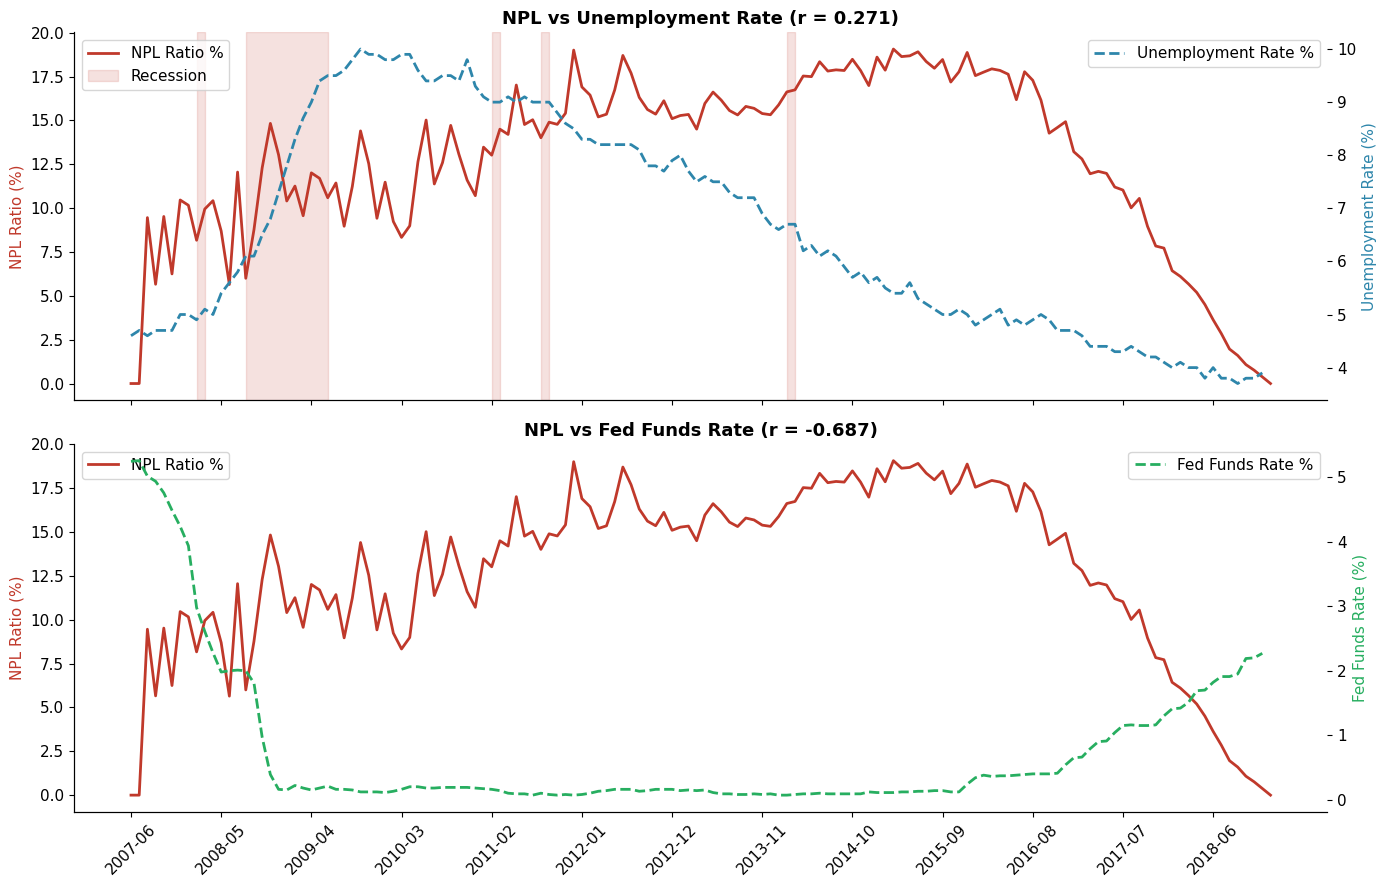

In [9]:
df_macro = conn.execute("""
    SELECT l.issue_month,
        ROUND(100.0 * SUM(CASE WHEN l.debt_group>=3 THEN 1 ELSE 0 END)/COUNT(*),4) AS npl_pct,
        m.unemployment_rate, m.fed_funds_rate,
        m.gdp_growth, m.recession_flag
    FROM pg.accepted_loans l
    LEFT JOIN pg.fred_macro m ON l.issue_month = m.issue_month
    WHERE l.issue_month IS NOT NULL
    GROUP BY l.issue_month, m.unemployment_rate,
             m.fed_funds_rate, m.gdp_growth, m.recession_flag
    ORDER BY l.issue_month
""").df()

# Tính correlation
corr_unemp = df_macro[["npl_pct","unemployment_rate"]].dropna().corr().iloc[0,1]
corr_fed   = df_macro[["npl_pct","fed_funds_rate"]].dropna().corr().iloc[0,1]
print(f"Correlation NPL vs Unemployment Rate : {corr_unemp:.4f}")
print(f"Correlation NPL vs Fed Funds Rate    : {corr_fed:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1 = axes[0]
ax1_r = ax1.twinx()
ax1.plot(df_macro["issue_month"], df_macro["npl_pct"],
         color=COLORS["red"], linewidth=2, label="NPL Ratio %")
ax1_r.plot(df_macro["issue_month"], df_macro["unemployment_rate"],
           color=COLORS["blue"], linewidth=2, linestyle="--", label="Unemployment Rate %")
# FIX M4: Recession shading — group months lien tiep thanh blocks [start, end]
rec = df_macro[df_macro["recession_flag"] == 1].copy()
if len(rec):
    rec_sorted = sorted(rec["issue_month"].tolist())
    blocks, s, p = [], rec_sorted[0], rec_sorted[0]
    for m in rec_sorted[1:]:
        diff = (pd.Period(str(m)[:7], "M") - pd.Period(str(p)[:7], "M")).n
        if diff > 2:
            blocks.append((s, p))
            s = m
        p = m
    blocks.append((s, p))
    labeled = False
    for (bs, be) in blocks:
        lbl = "Recession" if not labeled else "_nolegend_"
        ax1.axvspan(bs, be, alpha=0.15, color=COLORS["red"], label=lbl)
        labeled = True
    ax1.legend(loc="upper left")
ax1.set_title(f"NPL vs Unemployment Rate (r = {corr_unemp:.3f})")
ax1.set_ylabel("NPL Ratio (%)", color=COLORS["red"])
ax1_r.set_ylabel("Unemployment Rate (%)", color=COLORS["blue"])
ax1.legend(loc="upper left")
ax1_r.legend(loc="upper right")

ax2 = axes[1]
ax2_r = ax2.twinx()
ax2.plot(df_macro["issue_month"], df_macro["npl_pct"],
         color=COLORS["red"], linewidth=2, label="NPL Ratio %")
ax2_r.plot(df_macro["issue_month"], df_macro["fed_funds_rate"],
           color=COLORS["green"], linewidth=2, linestyle="--", label="Fed Funds Rate %")
ax2.set_title(f"NPL vs Fed Funds Rate (r = {corr_fed:.3f})")
ax2.set_ylabel("NPL Ratio (%)", color=COLORS["red"])
ax2_r.set_ylabel("Fed Funds Rate (%)", color=COLORS["green"])
ax2.legend(loc="upper left")
ax2_r.legend(loc="upper right")

step = max(1, len(df_macro)//12)
axes[1].set_xticks(df_macro["issue_month"][::step])
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("results/m4_macro_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
